# 02. Markov EDA: типизация атрибутов после BIO

Связка с выводами из `01_methods_eda`:
- хвосты вроде `g pro x se` часто остаются `O` — regex атрибутов их **не** ловит (это модель/линейка, не `16 гб`);
- идеал пайплайна: **сначала** `B/I-ATTR` (или более общие spans), **потом** тип атрибута;
- миллиард голов `memory/diagonal/...` не нужен → отдельный **типизатор** поверх ATTR.

Этот ноутбук: принцип Маркова, бейзлайн на биграммах, сравнение с расширенными правилами из `temp/labeling.py`, вердикт «имеет ли смысл» vs LogReg/RNN.


## 0. Setup

Импортируем **расширенную** карту `ATTR_PATTERNS` из `temp/labeling.py` (не урезанный `src/ner/labeling.py`).


In [1]:
%matplotlib inline
import sys
import importlib.util
from pathlib import Path
from collections import Counter, defaultdict
from dataclasses import dataclass

ROOT = Path.cwd().resolve()
if ROOT.name in {"complex_eda", "notebooks"}:
    ROOT = ROOT.parents[1] if ROOT.name == "complex_eda" else ROOT.parent
sys.path.insert(0, str(ROOT))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from src.data_utils import (
    apply_plot_style, ensure_dirs, load_query_clicks, ARTIFACTS_DIR, FIGURES_DIR,
    MVIDEO_RED, DARK_SLATE, MUTED, save_stats,
)
from src.ner.labeling import WeakLabeler, tokenize, bio_to_entities

# --- load temp/labeling.py ATTR map without breaking src package ---
_spec = importlib.util.spec_from_file_location("temp_labeling", ROOT / "temp" / "labeling.py")
temp_lab = importlib.util.module_from_spec(_spec)
sys.modules["temp_labeling"] = temp_lab
_spec.loader.exec_module(temp_lab)
TEMP_ATTR_PATTERNS = temp_lab.ATTR_PATTERNS
temp_tokenize = temp_lab.tokenize

ensure_dirs()
apply_plot_style()
FIG = FIGURES_DIR / "complex_eda" / "markov"
FIG.mkdir(parents=True, exist_ok=True)

def save_local(fig, name):
    p = FIG / name
    fig.savefig(p, dpi=160, bbox_inches="tight", facecolor="white")
    print("saved", p)
    return p

SAMPLE_N = 150_000
print("ROOT:", ROOT)
print("temp ATTR patterns:", len(TEMP_ATTR_PATTERNS))
print("types:", sorted({t for _, t in TEMP_ATTR_PATTERNS}))


ROOT: D:\Projects-26-06-2026\mvideo-ner-search
temp ATTR patterns: 28
types: ['age_restriction', 'airflow_capacity', 'area', 'connectivity', 'current', 'density', 'dimensions', 'flow_rate', 'frequency', 'impedance', 'ip_rating', 'magnification', 'megapixels', 'memory_storage', 'noise_level', 'pages_yield', 'power', 'quantity', 'resolution_exact', 'resolution_standard', 'rpm', 'size', 'temperature', 'time', 'voltage', 'volume', 'warranty_period', 'weight']


In [2]:
clicks = load_query_clicks(n=SAMPLE_N, seed=42, random=True)
ql = clicks["query_text"].astype(str).str.strip().str.lower()
uq = ql.drop_duplicates()
print(f"clicks={len(clicks):,}  unique_queries={uq.nunique():,}")
labeler = WeakLabeler.from_files(ARTIFACTS_DIR / "brands.txt", ARTIFACTS_DIR / "categories.txt")


clicks=150,000  unique_queries=39,428


## 1. Принцип: что именно предсказывает «марковская» типизация

### Пайплайн (двухступенчатый)

```text
query tokens
   → (A) span detection:  BIO ∈ {O, B-ATTR, I-ATTR, ...}
   → (B) attribute typing: span tokens → {memory_storage, size, power, ...}
```

Шаг (B) — это **классификатор типа**, а не второй NER.

### Модель 1-го порядка (идея «16 → гб ⇒ memory»)

Оцениваем по weak/regex-примерам условные частоты:

$$
P(t_{i+1} \mid t_i),\qquad
P(\text{type} \mid t_i, t_{i+1})
$$

Инференс для span `[16, гб]`:
1. смотрим биграмму `(16, гб)`;
2. берём argmax по эмпирическому $$P(\text{type}\mid 16, гб)$$  
   или эвристику: единица измерения (`гб`) → словарь типов.

Это **табличная / частотная** модель (сглаженный lookup), формально — марковская цепь / bigram Naive Bayes, **не** нейросеть.

### Markov ≈ правила?

| | Regex | Markov bigram | LogReg/RNN на span |
|---|---|---|---|
| Что хранит | явные шаблоны | частоты из данных | веса признаков / скрытое состояние |
| Новые формулировки | ломается | ловит, если встречались | обобщает лучше |
| Интерпретируемость | высокая | высокая | средняя/низкая |
| Нужны данные | нет | silver labels | silver/gold |
| Эквивалентность | — | **близко к выученным правилам** | нет |

**Вывод заранее:** чистый Markov на дискретных токенах **действительно близок к выученным правилам**. Смысл есть как:
1. **автоматический** способ собрать unit→type из данных (вместо ручного словаря);
2. бейзлайн перед LogReg/CRF-типизатором;
3. не как замена span-детекции для хвостов `g pro`.

RNN/Transformer на span имеет смысл, если тип зависит от **длинного/шумного** контекста (`ноут 16` без `гб`, омонимы `32` = Ом vs ГБ). На коротких запросах часто хватает bigram + словарь единиц.


## 2. Гипотеза про хвост `g pro`

Regex из `temp/labeling.py` ловит **число+единица** / стандарты (`4k`, `wifi`).  
Токены `g`, `pro`, `x`, `se` — линейка продукта → их должен ловить **словарь моделей / BRAND-алиасы / NER**, не ATTR-Markov.

Ниже измерим: какая доля «хвостовых» токенов после последней сущности похожа на ATTR-паттерн vs на буквенный хвост модели.


queries with O-tail after entity: 3963/8000 = 49.5%
among them, tail contains digit: 2307/3963 = 58.2%


,token,count
0,с,299
1,для,200
2,pro,184
3,",",82
4,на,81
5,15,65
6,4,61
7,2,60
8,5,60
9,ultra,56


saved D:\Projects-26-06-2026\mvideo-ner-search\figures\complex_eda\markov\01_entity_tails.png


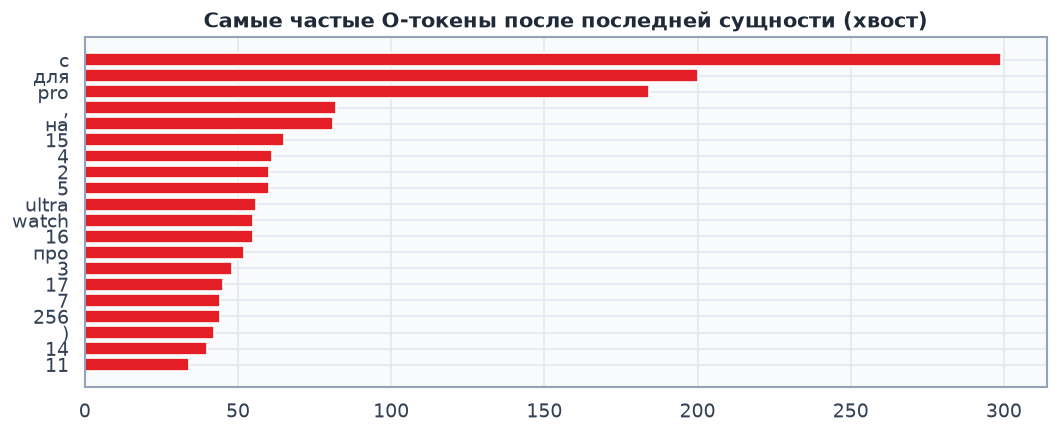

Примеры буквенного хвоста (модель/линейка) — Markov ATTR не поможет:
  вентилятор для компьютера → ['для', 'компьютера']
  погружной блендер braun multiquick → ['multiquick']
  духовой шкаф маленький → ['маленький']
  антенна телевизионная внешняя → ['телевизионная', 'внешняя']
  антенна активная уличная → ['активная', 'уличная']
Примеры хвоста с цифрой — кандидат в ATTR / typing:
  apple watch series 10 → ['watch', 'series', '10']
  xiaomi 13t → ['13t']
  чехлы для смартфонов samsung s 23+ → ['s', '23', '+']
  garlyn mg 2000 → ['mg', '2000']
  rf carrera crrf823 → ['crrf823']


In [3]:
def last_entity_tail(query: str):
    tags = labeler.label_query(query)
    if not tags:
        return []
    last_ent = -1
    for i, (_, t) in enumerate(tags):
        if t != "O":
            last_ent = i
    if last_ent < 0 or last_ent >= len(tags) - 1:
        return []
    return [tok for tok, t in tags[last_ent + 1:] if t == "O"]

rng = np.random.default_rng(42)
sample_q = uq.sample(n=min(8000, len(uq)), random_state=42).tolist()

tail_toks = Counter()
n_with_tail = 0
n_tail_looks_numeric = 0
examples_model_tail = []
examples_attrish = []

for q in sample_q:
    tail = last_entity_tail(q)
    if not tail:
        continue
    n_with_tail += 1
    for t in tail:
        tail_toks[t] += 1
    joined = " ".join(tail)
    if any(ch.isdigit() for ch in joined):
        n_tail_looks_numeric += 1
        if len(examples_attrish) < 8:
            examples_attrish.append((q, tail))
    else:
        if len(examples_model_tail) < 8:
            examples_model_tail.append((q, tail))

print(f"queries with O-tail after entity: {n_with_tail}/{len(sample_q)} = {n_with_tail/len(sample_q):.1%}")
print(f"among them, tail contains digit: {n_tail_looks_numeric}/{n_with_tail} = {n_tail_looks_numeric/max(n_with_tail,1):.1%}")

tail_df = pd.DataFrame(tail_toks.most_common(25), columns=["token", "count"])
display(tail_df.head(15))

fig, ax = plt.subplots(figsize=(9, 3.8))
top = tail_df.head(20)
ax.barh(top["token"][::-1], top["count"][::-1], color=MVIDEO_RED)
ax.set_title("Самые частые O-токены после последней сущности (хвост)")
fig.tight_layout()
save_local(fig, "01_entity_tails.png")
plt.show()

print("Примеры буквенного хвоста (модель/линейка) — Markov ATTR не поможет:")
for q, t in examples_model_tail[:5]:
    print(" ", q, "→", t)
print("Примеры хвоста с цифрой — кандидат в ATTR / typing:")
for q, t in examples_attrish[:5]:
    print(" ", q, "→", t)


## 3. Coverage: старые vs temp ATTR regex

Считаем, какую долю запросов закрывает расширенная карта из `temp/labeling.py`.


,source,n_patterns,share_queries_with_any_attr
0,src/ner/labeling.py,7,0.065433
1,temp/labeling.py,28,0.095133


saved D:\Projects-26-06-2026\mvideo-ner-search\figures\complex_eda\markov\02_temp_attr_coverage.png


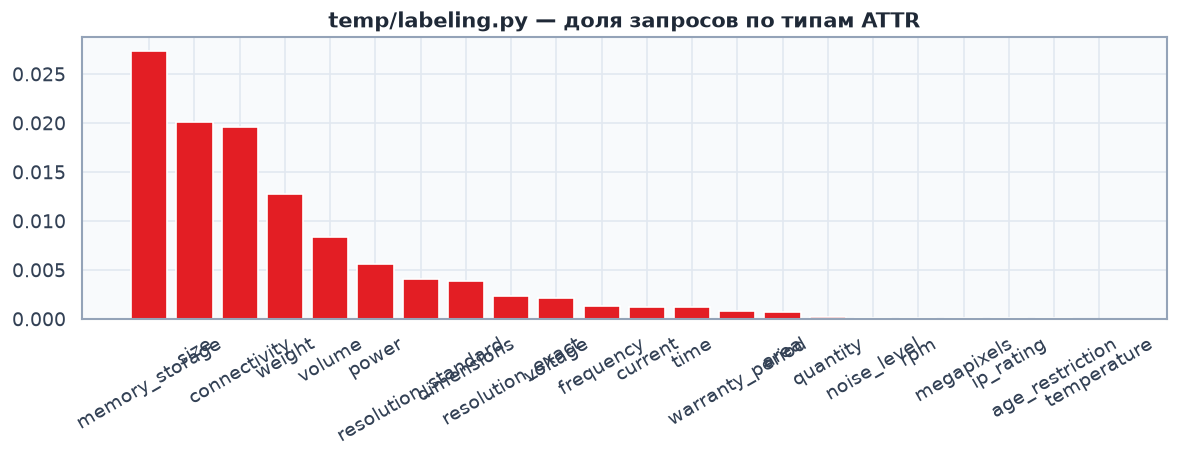

,attr_type,share
0,memory_storage,0.027367
1,size,0.020067
4,connectivity,0.019633
5,weight,0.012767
2,volume,0.008333
7,power,0.005600
8,resolution_standard,0.004100
6,dimensions,0.003900
11,resolution_exact,0.002300
10,voltage,0.002133


In [5]:
from src.ner.labeling import ATTR_PATTERNS as SRC_ATTR_PATTERNS

def coverage(queries, patterns):
    cov = Counter()
    any_hit = 0
    for q in queries:
        hit = False
        for pat, name in patterns:
            if pat.search(q):
                cov[name] += 1
                hit = True
        if hit:
            any_hit += 1
    return any_hit / len(queries), cov

# subsample for speed
cov_q = uq.sample(n=min(30_000, len(uq)), random_state=0).tolist()
any_src, cov_src = coverage(cov_q, SRC_ATTR_PATTERNS)
any_tmp, cov_tmp = coverage(cov_q, TEMP_ATTR_PATTERNS)

cmp = pd.DataFrame({
    "source": ["src/ner/labeling.py", "temp/labeling.py"],
    "n_patterns": [len(SRC_ATTR_PATTERNS), len(TEMP_ATTR_PATTERNS)],
    "share_queries_with_any_attr": [any_src, any_tmp],
})
display(cmp)

tmp_share = pd.DataFrame({
    "attr_type": list(cov_tmp.keys()),
    "share": [cov_tmp[k] / len(cov_q) for k in cov_tmp],
}).sort_values("share", ascending=False)

fig, ax = plt.subplots(figsize=(10, 4))
ax.bar(tmp_share["attr_type"], tmp_share["share"], color=MVIDEO_RED)
ax.set_title("temp/labeling.py — доля запросов по типам ATTR")
ax.tick_params(axis="x", rotation=30)
fig.tight_layout()
save_local(fig, "02_temp_attr_coverage.png")
plt.show()
display(tmp_share.head(12))


## 4. Бейзлайн Markov: собираем биграммы число→единица→тип

Из regex-матчей строим:
- `unit_to_types[unit] → Counter(types)`
- `bigram_to_types[(tok_i, tok_{i+1})] → Counter(types)`
- transition counts `P(next|prev)` среди токенов ATTR-спанов


extracted ATTR spans: 3537


,count
type,
memory_storage,914
connectivity,626
size,610
weight,385
volume,252
power,173
resolution_standard,146
dimensions,119
resolution_exact,69


,prev,next,count,top_type
36,60,см,93,size
11,256,гб,85,memory_storage
42,45,см,75,size
30,512,gb,71,memory_storage
12,256,gb,68,memory_storage
31,512,гб,60,memory_storage
54,50,см,50,size
0,1,tb,50,memory_storage
1,1,тб,48,memory_storage
92,7,кг,32,weight


saved D:\Projects-26-06-2026\mvideo-ner-search\figures\complex_eda\markov\03_markov_transitions.png


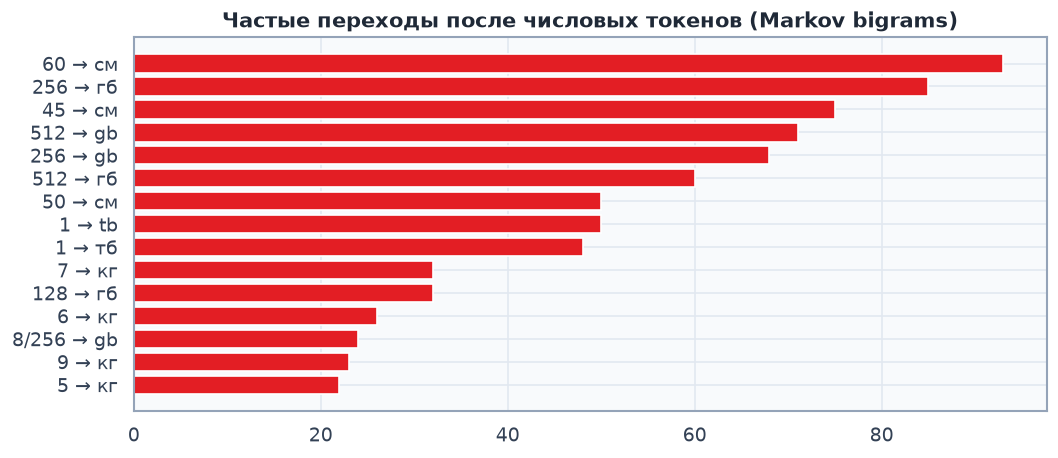

In [6]:
import re as _re

def span_tokens_from_match(query: str, start: int, end: int):
    # tokenize normalized like temp (split 128гб)
    toks = temp_tokenize(query)
    return [t for t, s, e in toks if not (e <= start or s >= end)]

records = []  # dicts: type, tokens, bigrams, units
UNIT_RE = _re.compile(r"^[а-яa-z°\"]{1,8}$", _re.I)

for q in cov_q:
    for pat, typ in TEMP_ATTR_PATTERNS:
        for m in pat.finditer(q):
            toks = [t.lower().replace("ё", "е") for t in span_tokens_from_match(q, m.start(), m.end())]
            if not toks:
                # fallback: split match text
                toks = [t for t in _re.split(r"\s+", m.group(0).lower()) if t]
            bigrams = list(zip(toks, toks[1:])) if len(toks) >= 2 else []
            units = [t for t in toks if UNIT_RE.match(t) and not t.isdigit()]
            records.append({"type": typ, "tokens": toks, "bigrams": bigrams, "units": units, "text": m.group(0)})

rec_df = pd.DataFrame(records)
print("extracted ATTR spans:", len(rec_df))
display(rec_df["type"].value_counts().head(15).to_frame("count"))

unit_to_types = defaultdict(Counter)
bigram_to_types = defaultdict(Counter)
trans = defaultdict(Counter)  # prev -> next counts inside spans

for r in records:
    for u in r["units"]:
        unit_to_types[u][r["type"]] += 1
    for bg in r["bigrams"]:
        bigram_to_types[bg][r["type"]] += 1
        trans[bg[0]][bg[1]] += 1

# top transitions after digits
digit_prev = {k: v for k, v in trans.items() if any(ch.isdigit() for ch in k)}
rows = []
for prev, nxts in digit_prev.items():
    for nxt, c in nxts.most_common(3):
        rows.append({"prev": prev, "next": nxt, "count": c, "top_type": unit_to_types[nxt].most_common(1)[0][0] if unit_to_types[nxt] else "?"})
trans_df = pd.DataFrame(rows).sort_values("count", ascending=False)
display(trans_df.head(20))

fig, ax = plt.subplots(figsize=(9, 4))
show = trans_df.head(15).copy()
show["edge"] = show["prev"] + " → " + show["next"]
ax.barh(show["edge"][::-1], show["count"][::-1], color=MVIDEO_RED)
ax.set_title("Частые переходы после числовых токенов (Markov bigrams)")
fig.tight_layout()
save_local(fig, "03_markov_transitions.png")
plt.show()


## 5. Инференс бейзлайна и качество на silver labels

Алгоритм `predict_type(tokens)`:
1. если биграмма известна → majority type;
2. иначе по единицам измерения;
3. иначе `unknown`.

Метрика: accuracy vs regex-тип на held-out spans (это **верхняя** оценка — учитель = те же правила; проверяем, воспроизводит ли Markov regex).


test spans=885  accuracy vs regex-teacher=0.619  unknown_rate=0.365


pred,memory_storage,connectivity,size,weight,volume,power,resolution_standard,dimensions,unknown
true,,,,,,,,,
memory_storage,172,0,0,0,0,0,0,0,41
connectivity,0,78,0,0,0,0,0,0,80
size,0,0,165,0,2,0,0,0,9
weight,1,0,0,46,0,0,0,0,49
volume,0,0,0,0,25,1,0,0,31
power,0,0,0,0,1,27,0,0,16
resolution_standard,0,0,0,0,0,0,8,0,36
dimensions,0,0,0,0,0,0,0,6,15


saved D:\Projects-26-06-2026\mvideo-ner-search\figures\complex_eda\markov\04_markov_confusion.png


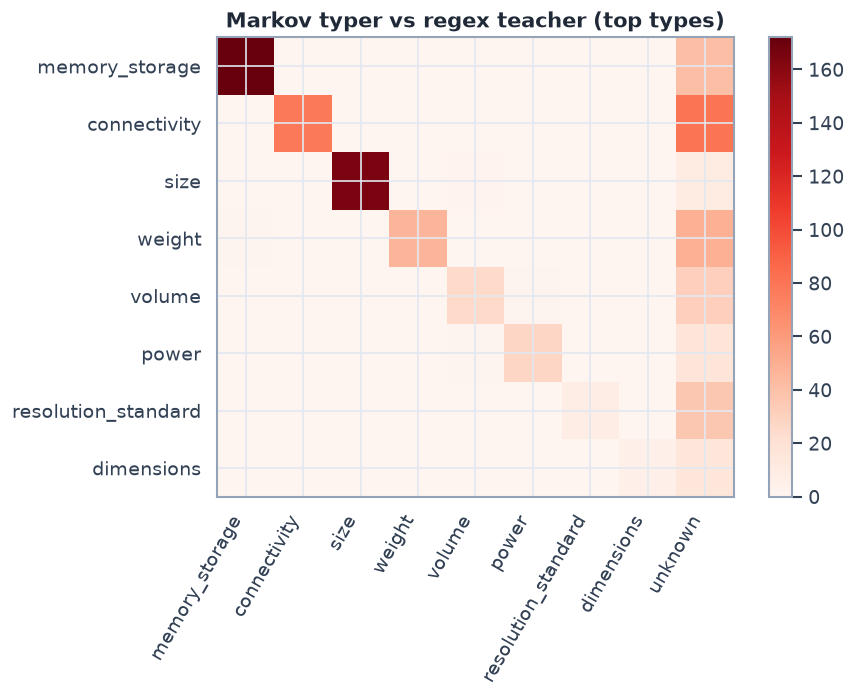

In [7]:
def predict_type(tokens: list[str]) -> str:
    toks = [t.lower().replace("ё", "е") for t in tokens]
    # bigrams
    scores = Counter()
    for bg in zip(toks, toks[1:]):
        scores.update(bigram_to_types.get(bg, {}))
    if scores:
        return scores.most_common(1)[0][0]
    for t in toks:
        if unit_to_types[t]:
            scores.update(unit_to_types[t])
    if scores:
        return scores.most_common(1)[0][0]
    return "unknown"

# train/test split of records
rng = np.random.default_rng(0)
idx = np.arange(len(records))
rng.shuffle(idx)
cut = int(0.75 * len(idx))
train_idx, test_idx = idx[:cut], idx[cut:]

# rebuild dictionaries on TRAIN only
unit_to_types = defaultdict(Counter)
bigram_to_types = defaultdict(Counter)
for i in train_idx:
    r = records[i]
    for u in r["units"]:
        unit_to_types[u][r["type"]] += 1
    for bg in r["bigrams"]:
        bigram_to_types[bg][r["type"]] += 1

y_true, y_pred = [], []
for i in test_idx:
    r = records[i]
    y_true.append(r["type"])
    y_pred.append(predict_type(r["tokens"]))

acc = float(np.mean([a == b for a, b in zip(y_true, y_pred)]))
unk = float(np.mean([p == "unknown" for p in y_pred]))
print(f"test spans={len(test_idx)}  accuracy vs regex-teacher={acc:.3f}  unknown_rate={unk:.3f}")

cm = pd.crosstab(pd.Series(y_true, name="true"), pd.Series(y_pred, name="pred"))
# show top types only
top_types = rec_df["type"].value_counts().head(8).index.tolist() + ["unknown"]
cm2 = cm.reindex(index=[t for t in top_types if t in cm.index], columns=[t for t in top_types if t in cm.columns], fill_value=0)
display(cm2)

# confusion heatmap (small)
fig, ax = plt.subplots(figsize=(8, 6))
im = ax.imshow(cm2.values, cmap="Reds")
ax.set_xticks(range(cm2.shape[1]))
ax.set_yticks(range(cm2.shape[0]))
ax.set_xticklabels(cm2.columns, rotation=60, ha="right")
ax.set_yticklabels(cm2.index)
ax.set_title("Markov typer vs regex teacher (top types)")
fig.colorbar(im, ax=ax, fraction=0.046)
fig.tight_layout()
save_local(fig, "04_markov_confusion.png")
plt.show()


## 6. Когда Markov НЕ поможет: омонимы и отсутствие единицы

Примеры, где нужна более сильная модель (LogReg на контексте / RNN / весь query):
- `32` без единицы — память? сопротивление? размер?
- `55` — дюймы TV vs что-то ещё
- тип зависит от категории (`наушники 32` vs `ssd 32`)


,number_token,n_types,total,distribution
4,5,10,360,"{'weight': 170, 'connectivity': 146, 'volume':..."
21,12,10,46,"{'memory_storage': 20, 'warranty_period': 15, ..."
19,4,9,162,"{'resolution_standard': 74, 'weight': 36, 'con..."
14,2,9,74,"{'memory_storage': 33, 'resolution_standard': ..."
15,3,9,43,"{'voltage': 17, 'volume': 10, 'size': 6, 'weig..."
0,1,8,135,"{'memory_storage': 102, 'volume': 15, 'weight'..."
23,100,8,29,"{'volume': 11, 'power': 7, 'size': 3, 'voltage..."
16,6,7,52,"{'weight': 29, 'volume': 14, 'memory_storage':..."
18,9,7,39,"{'weight': 24, 'volume': 4, 'voltage': 4, 'cur..."
3,20,7,34,"{'size': 12, 'power': 11, 'volume': 5, 'voltag..."


saved D:\Projects-26-06-2026\mvideo-ner-search\figures\complex_eda\markov\05_number_ambiguity.png


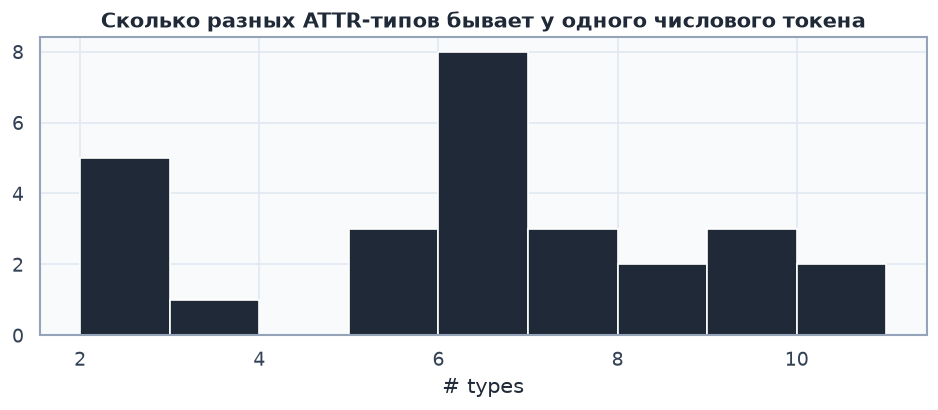

Вердикт: при наличии единицы Markov ≈ выученное правило (ок как бейзлайн).
Без единицы / при омонимии нужен контекст категории → LogReg(span+query) или лёгкий RNN/Transformer.


In [8]:
# ambiguous numbers: same number token appears in multiple ATTR types
num_types = defaultdict(Counter)
for r in records:
    for t in r["tokens"]:
        if any(ch.isdigit() for ch in t):
            num_types[t][r["type"]] += 1

amb = []
for num, ctr in num_types.items():
    if len(ctr) >= 2 and sum(ctr.values()) >= 20:
        amb.append({
            "number_token": num,
            "n_types": len(ctr),
            "total": sum(ctr.values()),
            "distribution": dict(ctr.most_common(4)),
        })
amb_df = pd.DataFrame(amb).sort_values(["n_types", "total"], ascending=False)
display(amb_df.head(15))

fig, ax = plt.subplots(figsize=(8, 3.6))
ax.hist(amb_df["n_types"], bins=range(2, int(amb_df["n_types"].max()) + 2), color=DARK_SLATE, edgecolor="white")
ax.set_title("Сколько разных ATTR-типов бывает у одного числового токена")
ax.set_xlabel("# types")
fig.tight_layout()
save_local(fig, "05_number_ambiguity.png")
plt.show()

print("Вердикт: при наличии единицы Markov ≈ выученное правило (ок как бейзлайн).")
print("Без единицы / при омонимии нужен контекст категории → LogReg(span+query) или лёгкий RNN/Transformer.")


## 7. Практический вердикт и план

| Вопрос | Ответ |
|---|---|
| Имеет ли смысл Markov? | **Да как бейзлайн типизации** и автосбор unit→type из `temp` regex |
| Эквивалентен ли правилам? | **Почти**, если признаки = те же токены; плюс — частоты из данных |
| Нужна ли сразу RNN? | **Не обязательно.** Сначала: BIO ATTR → Markov/LogReg typer. RNN — если gold покажет ошибку на омонимах |
| Починит ли `g pro`? | **Нет.** Это не ATTR; нужны словарь линеек / NER на MODEL / brand aliases |
| Масштабирование | O(|V|^2) биграмм редко плотно; на практике — hashmap по встреченным биграммам, RAM крошечный, latency << 1 мс |

### Рекомендуемый следующий шаг
1. Перенести `temp/labeling.py` ATTR map (+ улучшенный `tokenize`) в `src/ner/labeling.py`.
2. Детект span: словари + CRF (`B-ATTR`).
3. Typing: Markov/unit lexicon → затем LogReg(`tokens + category_hint`).
4. Отдельно: словарь product-line (`g pro`, `v15`, `air`) как `MODEL` или часть BRAND.


In [9]:
out = {
    "sample_clicks": int(len(clicks)),
    "temp_n_patterns": len(TEMP_ATTR_PATTERNS),
    "src_n_patterns": len(SRC_ATTR_PATTERNS),
    "attr_coverage_src": float(any_src),
    "attr_coverage_temp": float(any_tmp),
    "n_attr_spans": int(len(records)),
    "markov_test_accuracy_vs_regex": float(acc),
    "markov_unknown_rate": float(unk),
    "n_ambiguous_numbers": int(len(amb_df)),
    "queries_with_entity_tail_rate": float(n_with_tail / len(sample_q)),
    "tail_with_digit_rate": float(n_tail_looks_numeric / max(n_with_tail, 1)),
}
save_stats(out, "markov_attr_eda_stats.json")
pd.DataFrame(list(out.items()), columns=["metric", "value"])


Статистика сохранена: D:\Projects-26-06-2026\mvideo-ner-search\artifacts\markov_attr_eda_stats.json


,metric,value
0,sample_clicks,150000.000000
1,temp_n_patterns,28.000000
2,src_n_patterns,7.000000
3,attr_coverage_src,0.065433
4,attr_coverage_temp,0.095133
5,n_attr_spans,3537.000000
6,markov_test_accuracy_vs_regex,0.619209
7,markov_unknown_rate,0.364972
8,n_ambiguous_numbers,27.000000
9,queries_with_entity_tail_rate,0.495375
